In [3]:
# Imports & configuration (SVM)
import os, math, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, f1_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

DATA_DIR = '..'  # relative to notebooks folder
TRAIN_PATH = os.path.join(DATA_DIR, 'train.csv')
TEST_PATH = os.path.join(DATA_DIR, 'test.csv')
SUB_SAMPLE_PATH = os.path.join(DATA_DIR, 'sample_submission.csv')
OUTPUT_PATH = os.path.join(DATA_DIR, 'svm.csv')

# Load data
train = pd.read_csv('/Users/vaishak/Desktop/Chronic_disease_ML/chronic-obstructive-pulmonary-disease-copd-risk/train.csv')
test = pd.read_csv('/Users/vaishak/Desktop/Chronic_disease_ML/chronic-obstructive-pulmonary-disease-copd-risk/test.csv')
print('Train shape:', train.shape, 'Test shape:', test.shape)
print('Columns:', train.columns.tolist())

target_col = 'has_copd_risk'
assert target_col in train.columns, 'Target column not found in train.csv'

# Identify feature columns
id_col = 'patient_id'
feature_cols = [c for c in train.columns if c not in [target_col, id_col]]
print('Feature count:', len(feature_cols))

# Basic stats
display(train[feature_cols].describe().T)
print(train[target_col].value_counts(normalize=True))

Train shape: (44553, 27) Test shape: (11139, 26)
Columns: ['patient_id', 'sex', 'age_group', 'height_cm', 'weight_kg', 'waist_circumference_cm', 'vision_left', 'vision_right', 'hearing_left', 'hearing_right', 'bp_systolic', 'bp_diastolic', 'fasting_glucose', 'total_cholesterol', 'triglycerides', 'hdl_cholesterol', 'ldl_cholesterol', 'hemoglobin_level', 'urine_protein_level', 'serum_creatinine', 'ast_enzyme_level', 'alt_enzyme_level', 'ggt_enzyme_level', 'oral_health_status', 'dental_cavity_status', 'tartar_presence', 'has_copd_risk']
Feature count: 25


,count,mean,std,min,25%,50%,75%,max
age_group,44553.0,44.192647,12.080415,20.0,40.0,40.0,55.0,85.0
height_cm,44553.0,164.658946,9.193424,135.0,160.0,165.0,170.0,190.0
weight_kg,44553.0,65.877382,12.806358,30.0,55.0,65.0,75.0,135.0
waist_circumference_cm,44553.0,82.058993,9.274225,51.0,76.0,82.0,88.0,129.0
vision_left,44553.0,1.012484,0.484290,0.1,0.8,1.0,1.2,9.9
vision_right,44553.0,1.007086,0.485292,0.1,0.8,1.0,1.2,9.9
hearing_left,44553.0,1.025543,0.157768,1.0,1.0,1.0,1.0,2.0
hearing_right,44553.0,1.026777,0.161433,1.0,1.0,1.0,1.0,2.0
bp_systolic,44553.0,121.491796,13.724801,71.0,112.0,120.0,130.0,240.0
bp_diastolic,44553.0,76.000988,9.711986,40.0,70.0,76.0,82.0,146.0


has_copd_risk
0    0.633178
1    0.366822
Name: proportion, dtype: float64


Numeric features: 22


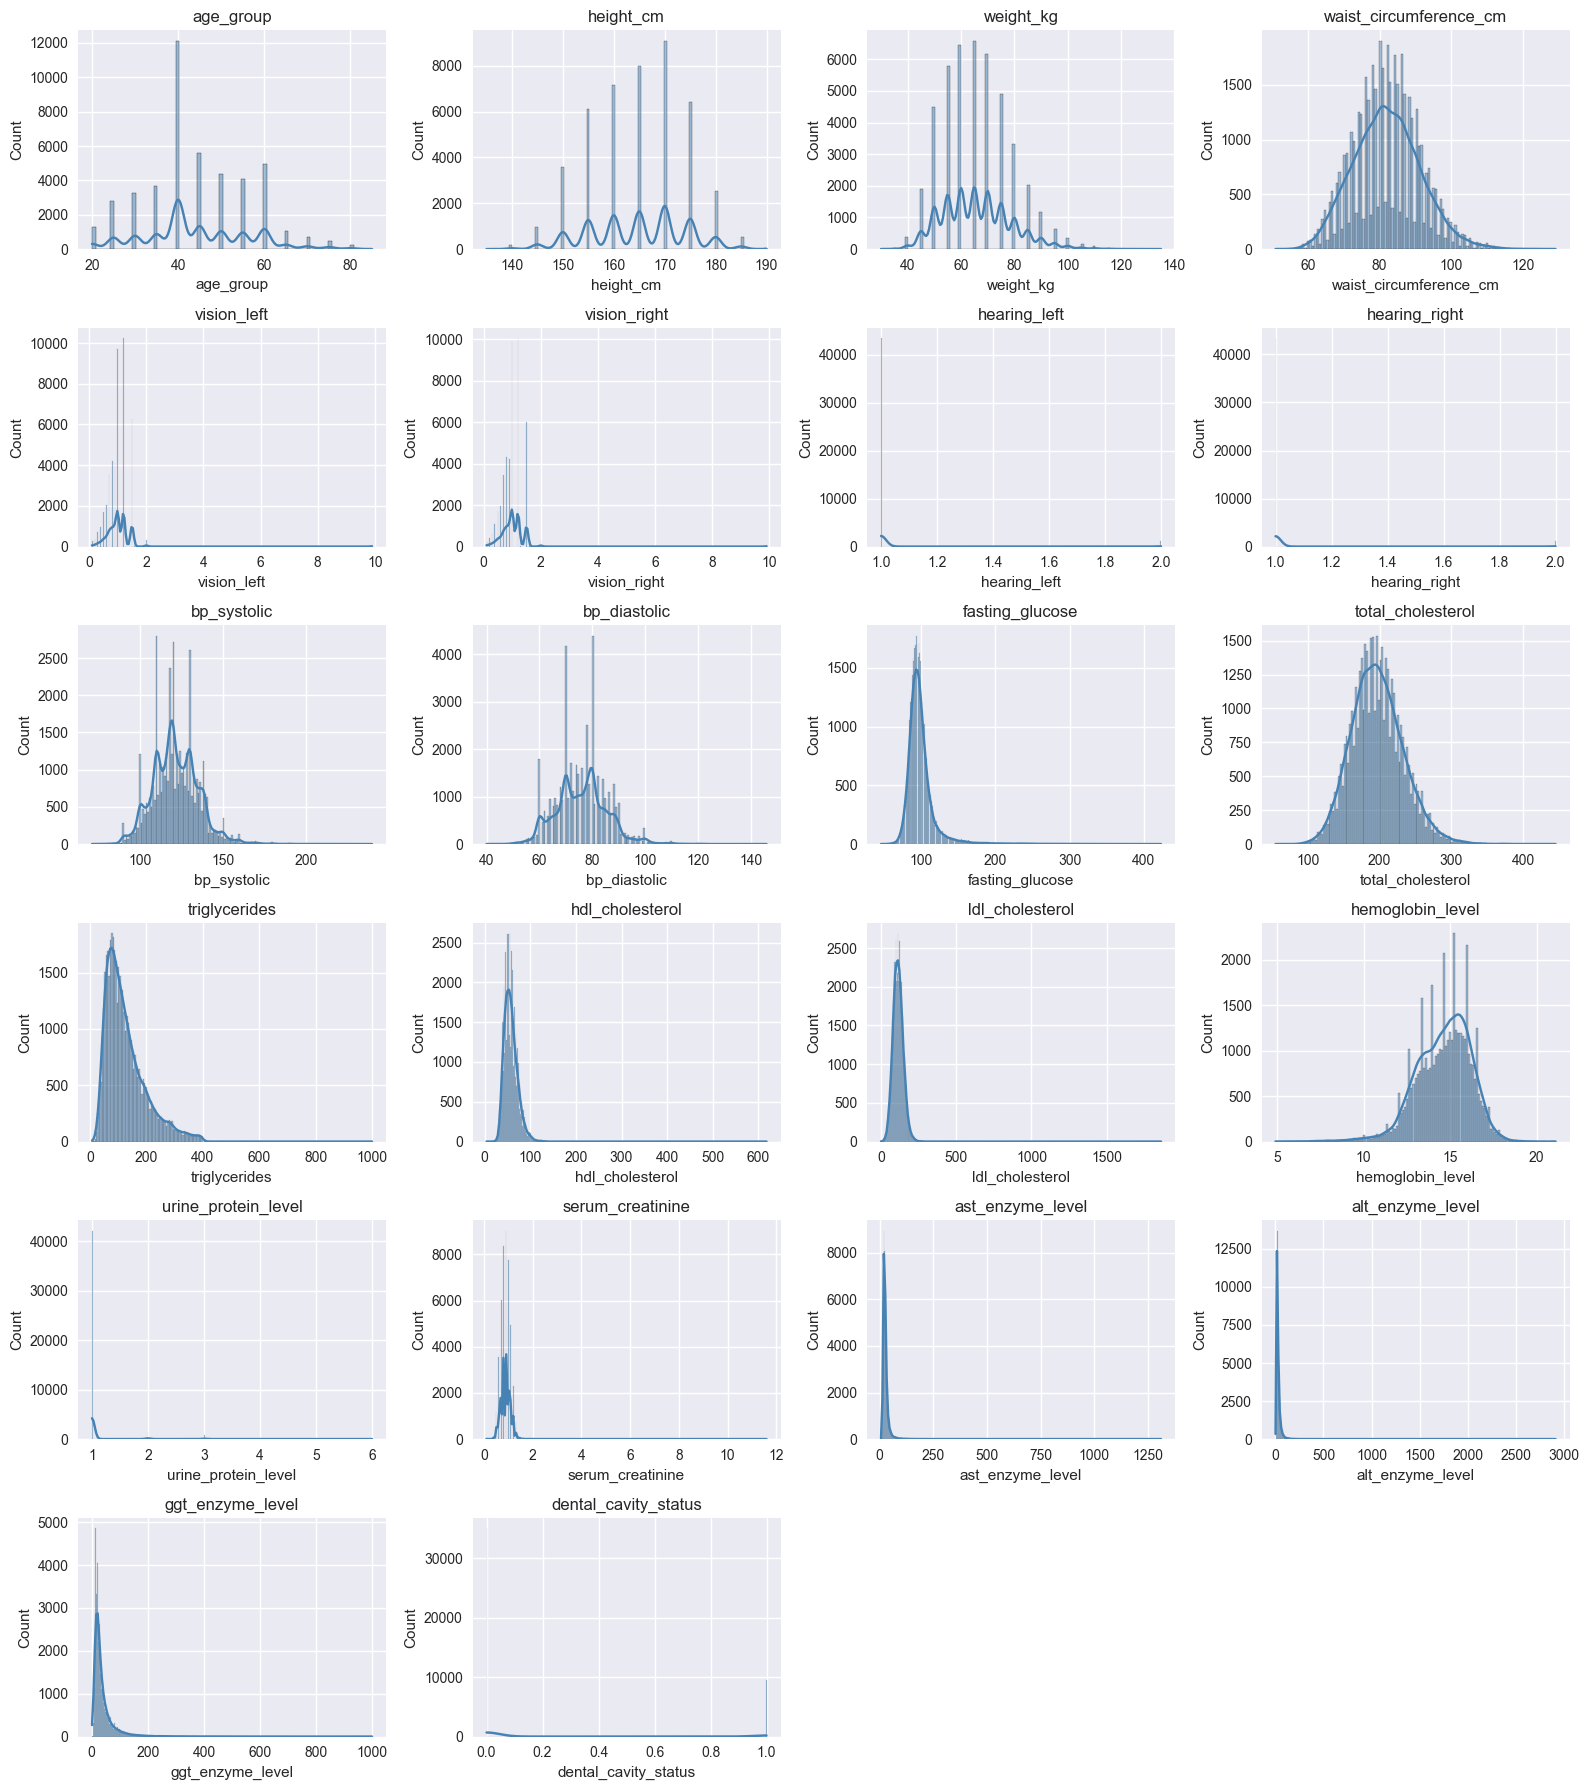

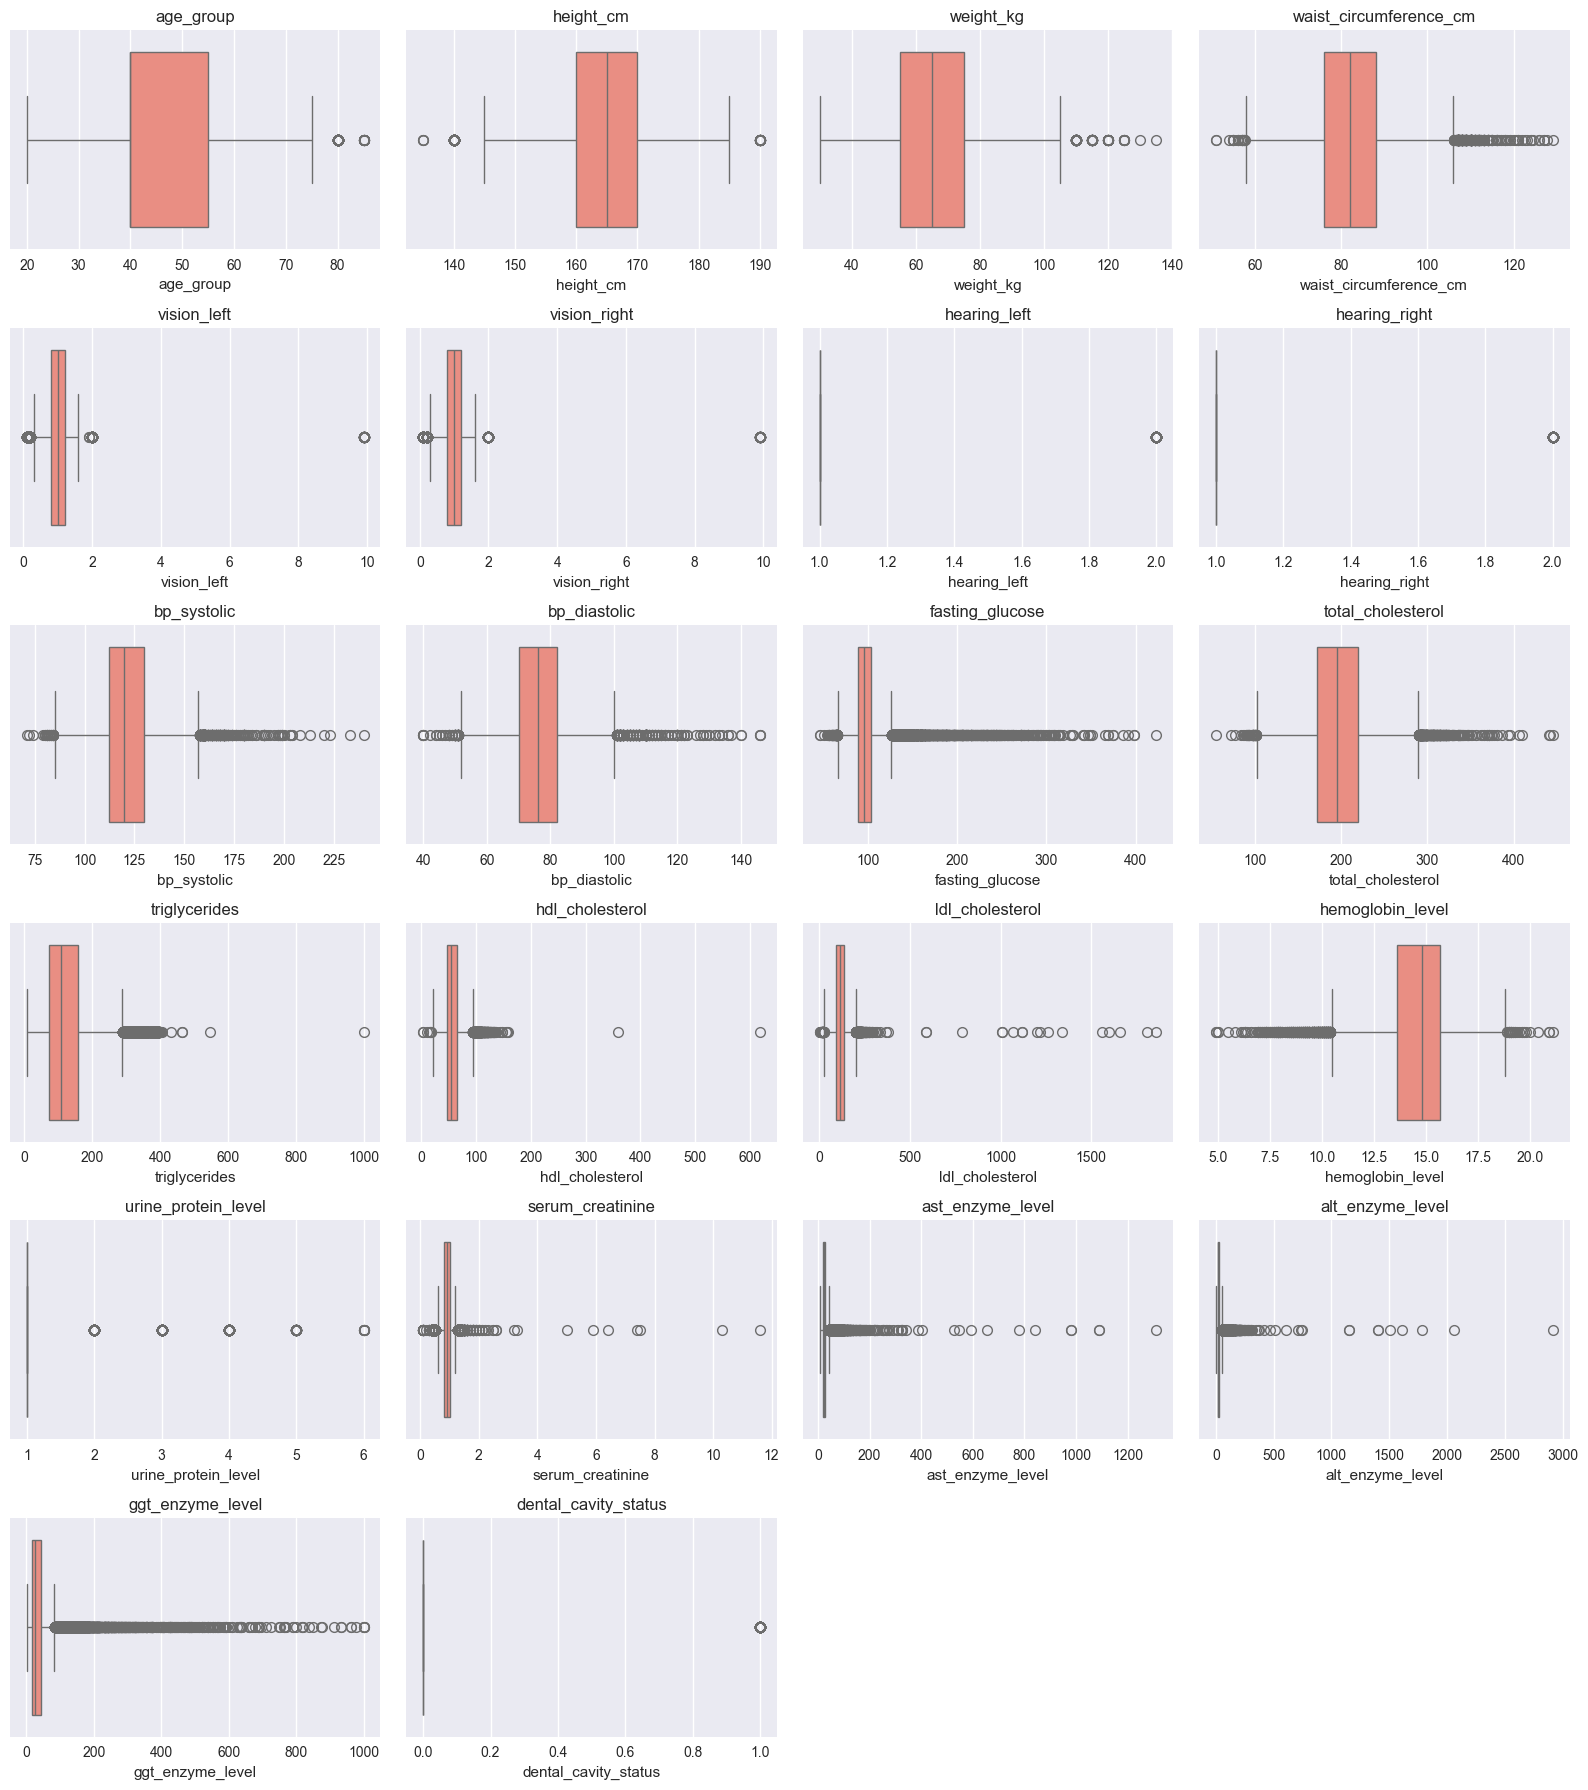

Value counts for sex:
sex
M    28326
F    16227
Name: count, dtype: int64
----------------------------------------
Value counts for oral_health_status:
oral_health_status
Y    44553
Name: count, dtype: int64
----------------------------------------
Value counts for tartar_presence:
tartar_presence
Y    24742
N    19811
Name: count, dtype: int64
----------------------------------------


In [4]:
# EDA: Histograms for numeric features
numeric_cols = [c for c in feature_cols if train[c].dtype != 'object']
print('Numeric features:', len(numeric_cols))

n_cols = 4
n_rows = math.ceil(len(numeric_cols)/n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    sns.histplot(train[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
for ax in axes[len(numeric_cols):]:
    ax.remove()
plt.tight_layout()
plt.show()

# Boxplots (potential outliers)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x=train[col], ax=ax, color='salmon')
    ax.set_title(col)
for ax in axes[len(numeric_cols):]:
    ax.remove()
plt.tight_layout()
plt.show()

# Categorical value counts
categorical_cols = [c for c in feature_cols if train[c].dtype == 'object']
for c in categorical_cols:
    print(f'Value counts for {c}:')
    print(train[c].value_counts())
    print('-'*40)

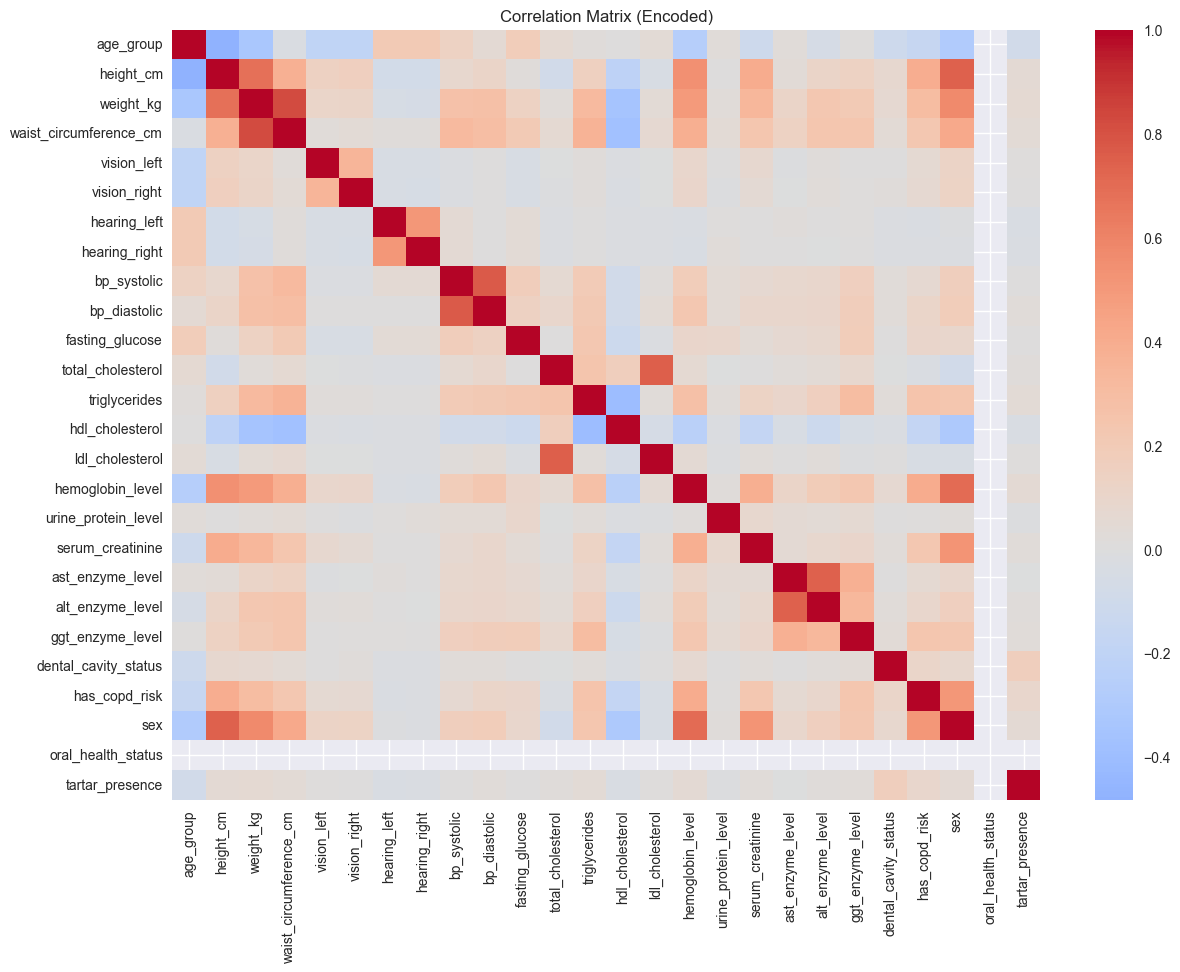

Top correlations with target:
sex                       0.510569
hemoglobin_level          0.402280
height_cm                 0.394175
weight_kg                 0.301453
triglycerides             0.253442
ggt_enzyme_level          0.239765
serum_creatinine          0.225580
waist_circumference_cm    0.224711
hdl_cholesterol          -0.177540
age_group                -0.163253
bp_diastolic              0.108448
dental_cavity_status      0.104297
fasting_glucose           0.097504
tartar_presence           0.096917
alt_enzyme_level          0.092264
bp_systolic               0.072169
vision_right              0.065009
vision_left               0.059228
ast_enzyme_level          0.058897
ldl_cholesterol          -0.044931
total_cholesterol        -0.027961
hearing_left             -0.024632
hearing_right            -0.021527
urine_protein_level       0.014028
oral_health_status             NaN
Name: has_copd_risk, dtype: float64


In [5]:
# Correlation matrix (numeric only with target encoded)
# Encode categorical features temporarily for correlation (simple ordinal encoding)
encoded = train.copy()
for c in [c for c in categorical_cols if c != target_col]:
    encoded[c] = encoded[c].astype('category').cat.codes
encoded[target_col] = encoded[target_col].astype('category').cat.codes

corr_matrix = encoded[numeric_cols + [target_col] + [c for c in categorical_cols if c != target_col]].corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Encoded)')
plt.show()

# Correlation of individual features with target
feature_target_corr = corr_matrix[target_col].drop(target_col).sort_values(key=lambda s: s.abs(), ascending=False)
print('Top correlations with target:')
print(feature_target_corr.head(30))

In [6]:
# Advanced Feature Engineering (normalized + pruned interactions)
# 1) Normalize heavy-tailed features
LOG1P_COLS = ['ast_enzyme_level', 'alt_enzyme_level', 'ggt_enzyme_level', 'triglycerides']

# 2) Configure correlation cutoff BEFORE engineering (adjust here)
#    Increase to 0.12–0.15 to be stricter

BASE_CORR_THR = 0.15  # <--- change this value to tune pre-selection

# 3) Ratio whitelist (single-direction only)
RATIO_WHITELIST = [('waist_circumference_cm', 'height_cm')]  # compute waist/height only

# Recompute base frame
base_df = train[feature_cols].copy()
const_cols = [c for c in base_df.columns if base_df[c].nunique() == 1]
if const_cols:
    base_df = base_df.drop(columns=const_cols)

# Encode categoricals to numeric and detect binaries
for c in base_df.columns:
    if base_df[c].dtype == 'object':
        base_df[c] = base_df[c].astype('category').cat.codes

# Apply log1p to heavy-tailed columns where present
for c in LOG1P_COLS:
    if c in base_df.columns:
        base_df[c] = np.log1p(base_df[c])

# Target encoding and base correlations
y_enc = train[target_col].astype('category').cat.codes
corr_vec = base_df.assign(_target=y_enc).corr()['_target'].drop('_target')

# Identify candidate interaction drivers
high_corr_features = corr_vec[corr_vec.abs() >= BASE_CORR_THR].index.tolist()
print('High correlation features (>= BASE_CORR_THR):', high_corr_features)
print('Total base features after constant-drop:', base_df.shape[1])

# Determine continuous (non-binary) numeric features for interactions
is_binary = {c: (base_df[c].nunique() == 2) for c in base_df.columns}
continuous_cols = [c for c in base_df.columns if base_df[c].dtype != 'object' and not is_binary[c]]
print('Continuous columns considered for interactions:', len(continuous_cols))

# Prepare test frame with identical preprocessing
base_test_df = test[feature_cols].copy()
if const_cols:
    for c in const_cols:
        if c in base_test_df.columns:
            base_test_df = base_test_df.drop(columns=c)
for c in base_test_df.columns:
    if base_test_df[c].dtype == 'object':
        base_test_df[c] = base_test_df[c].astype('category').cat.codes
for c in LOG1P_COLS:
    if c in base_test_df.columns:
        base_test_df[c] = np.log1p(base_test_df[c])

engineered_train = {}
engineered_test = {}

# 4) Interactions: only products and squares for continuous-continuous pairs; exclude binaries
drivers = [h for h in high_corr_features if h in continuous_cols]
base_features = [f for f in continuous_cols]

mult_count = 0
sq_count = 0
ratio_count = 0

for h in drivers:
    for f in base_features:
        if f == h:
            continue
        # product
        name_mul = f'{h}__x__{f}'
        engineered_train[name_mul] = base_df[h] * base_df[f]
        engineered_test[name_mul] = base_test_df[h] * base_test_df[f]
        mult_count += 1
    # square
    name_sq = f'{h}__sq'
    engineered_train[name_sq] = base_df[h] ** 2
    engineered_test[name_sq] = base_test_df[h] ** 2
    sq_count += 1

# 5) Single-direction safe ratios (whitelist only)
for num, den in RATIO_WHITELIST:
    if num in base_df.columns and den in base_df.columns:
        den_train = base_df[den].replace(0, np.nan)
        den_test = base_test_df[den].replace(0, np.nan)
        name_ratio = f'{num}__div__{den}'
        engineered_train[name_ratio] = (base_df[num] / den_train).fillna(0)
        engineered_test[name_ratio] = (base_test_df[num] / den_test).fillna(0)
        ratio_count += 1

print(f'Generated counts -> mult:{mult_count} squares:{sq_count} ratios_whitelist:{ratio_count}')

eng_train_df = pd.DataFrame(engineered_train)
eng_test_df = pd.DataFrame(engineered_test)

# 6) Correlation of engineered features with target
eng_corr_vec = eng_train_df.assign(_target=y_enc).corr()['_target'].drop('_target')
eng_corr_sorted = eng_corr_vec.sort_values(key=lambda s: s.abs(), ascending=False)
print('Top engineered correlations (abs):')
print(eng_corr_sorted.head(20))

# 7) Remove near-duplicate engineered features (|corr| > 0.9) greedily by target correlation order
FEAT_DUP_THR = 0.9
selected = []
eng_cols = eng_corr_sorted.index.tolist()
for col in eng_cols:
    keep = True
    for kept in selected:
        r = eng_train_df[[kept, col]].corr().iloc[0,1]
        if np.isnan(r):
            continue
        if abs(r) > FEAT_DUP_THR:
            keep = False
            break
    if keep:
        selected.append(col)
print(f'After duplicate pruning: kept {len(selected)} / {len(eng_cols)} engineered features')

# 8) Save engineered correlation vector
corr_out_path = 'feature_target_correlation.csv'
eng_corr_sorted.to_csv(corr_out_path, header=['corr_with_target'])
print('Saved engineered correlation vector to', corr_out_path)

# 9) Build final model matrices (one-hot for original categoricals)
X_orig = train[feature_cols].drop(columns=const_cols)
X_test_orig = test[feature_cols].drop(columns=const_cols)
X_model = pd.get_dummies(X_orig, columns=[c for c in X_orig.columns if X_orig[c].dtype=='object'], drop_first=True)
X_test_model = pd.get_dummies(X_test_orig, columns=[c for c in X_test_orig.columns if X_test_orig[c].dtype=='object'], drop_first=True)
X_test_model = X_test_model.reindex(columns=X_model.columns, fill_value=0)

# Append engineered subset
X_model = pd.concat([X_model, eng_train_df[selected]], axis=1)
X_test_model = pd.concat([X_test_model, eng_test_df[selected]], axis=1)

print('Final model shapes:', X_model.shape, X_test_model.shape)

# Expose for training cell
X_final = X_model
X_test_final = X_test_model


High correlation features (>= BASE_CORR_THR): ['sex', 'age_group', 'height_cm', 'weight_kg', 'waist_circumference_cm', 'triglycerides', 'hdl_cholesterol', 'hemoglobin_level', 'serum_creatinine', 'alt_enzyme_level', 'ggt_enzyme_level']
Total base features after constant-drop: 24
Continuous columns considered for interactions: 19
Generated counts -> mult:180 squares:10 ratios_whitelist:1
Top engineered correlations (abs):
hemoglobin_level__x__height_cm                 0.447695
height_cm__x__hemoglobin_level                 0.447695
hemoglobin_level__x__ggt_enzyme_level          0.435621
ggt_enzyme_level__x__hemoglobin_level          0.435621
height_cm__x__ggt_enzyme_level                 0.422210
ggt_enzyme_level__x__height_cm                 0.422210
triglycerides__x__hemoglobin_level             0.411090
hemoglobin_level__x__triglycerides             0.411090
hemoglobin_level__sq                           0.407006
height_cm__sq                                  0.391500
ggt_enzyme_level

In [7]:
# Model Training (SVM with probability calibration)
RANDOM_STATE = 42
X_train, X_valid, y_train, y_valid = train_test_split(X_final, y_enc, test_size=0.2, stratify=y_enc, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_valid_s = scaler.transform(X_valid)
X_test_s = scaler.transform(X_test_final)

svc = SVC(kernel='rbf', C=2.0, gamma='scale', probability=True, class_weight='balanced')
svc.fit(X_train_s, y_train)

valid_probs = svc.predict_proba(X_valid_s)[:,1]
valid_preds = (valid_probs >= 0.5).astype(int)
print('Validation ROC AUC:', roc_auc_score(y_valid, valid_probs))
print('Validation F1 (0.5 thr):', f1_score(y_valid, valid_preds))
print(classification_report(y_valid, valid_preds))

# Threshold sweep for best F1
thr_grid = np.linspace(0.1, 0.9, 41)
best_f1, best_thr = -1, 0.5
for thr in thr_grid:
    preds_thr = (valid_probs >= thr).astype(int)
    f1_val = f1_score(y_valid, preds_thr)
    if f1_val > best_f1:
        best_f1, best_thr = f1_val, thr
print(f'Best threshold: {best_thr:.3f} | F1: {best_f1:.4f}')

# Final test predictions
test_probs = svc.predict_proba(X_test_s)[:,1]
test_preds = (test_probs >= best_thr).astype(int)
submission = pd.DataFrame({id_col: test[id_col], target_col: test_preds})
submission.to_csv(OUTPUT_PATH, index=False)
print('Saved predictions to', OUTPUT_PATH)
submission.head()

Validation ROC AUC: 0.8425852559502981
Validation F1 (0.5 thr): 0.709278350515464
              precision    recall  f1-score   support

           0       0.86      0.75      0.80      5642
           1       0.64      0.79      0.71      3269

    accuracy                           0.76      8911
   macro avg       0.75      0.77      0.75      8911
weighted avg       0.78      0.76      0.77      8911

Best threshold: 0.340 | F1: 0.7193
Saved predictions to ../svm.csv
Saved predictions to ../svm.csv


,patient_id,has_copd_risk
0,42427,0
1,27412,0
2,19283,1
3,45261,1
4,11155,1
